# Explainable Credit Risk Prediction Using Machine Learning

**CS465 Machine Learning Course Project**

This notebook implements a complete end-to-end pipeline for credit risk prediction on the UCI German Credit Dataset, comparing four classical machine learning models with a focus on both predictive performance and explainability.

## A. Imports and Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available - SHAP analysis will be skipped.")

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Resolve project root robustly whether run from notebooks/ or project root
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd

DATA_PATH   = PROJECT_ROOT / 'data'    / 'raw'     / 'german.data'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR  = PROJECT_ROOT / 'results' / 'tables'
METRICS_DIR = PROJECT_ROOT / 'results' / 'metrics'

for d in (FIGURES_DIR, TABLES_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT.resolve()}')
print(f'DATA_PATH    : {DATA_PATH.resolve()}')
print(f'FIGURES_DIR  : {FIGURES_DIR.resolve()}')
print(f'Random seed  : {RANDOM_SEED}')
print('Setup complete.')

SHAP not available - SHAP analysis will be skipped.
PROJECT_ROOT : /Users/mahmood/Desktop/cs465_project
DATA_PATH    : /Users/mahmood/Desktop/cs465_project/data/raw/german.data
FIGURES_DIR  : /Users/mahmood/Desktop/cs465_project/results/figures
Random seed  : 42
Setup complete.


## B. Data Loading

In [2]:
column_names = [
    'status_checking_account', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_since', 'installment_rate',
    'personal_status_sex', 'other_debtors_guarantors', 'present_residence_since',
    'property', 'age_years', 'other_installment_plans', 'housing', 'existing_credits',
    'job', 'num_dependents', 'telephone', 'foreign_worker', 'target'
]

try:
    df = pd.read_csv(DATA_PATH, sep=r'\s+', header=None, names=column_names)
    print(f'Dataset loaded successfully. Shape: {df.shape}')
except FileNotFoundError:
    print(f'ERROR: Dataset not found at {DATA_PATH.resolve()}')
    raise

# Remap target: 1 (good credit) -> 0, 2 (bad credit) -> 1
df['target'] = df['target'].map({1: 0, 2: 1})
assert df['target'].isin([0, 1]).all(), 'Target mapping failed.'

print('Target mapping: 1->0 (Good Credit), 2->1 (Bad Credit)')
print(df['target'].value_counts().sort_index().rename({0: 'Good Credit (0)', 1: 'Bad Credit (1)'}))

Dataset loaded successfully. Shape: (1000, 21)
Target mapping: 1->0 (Good Credit), 2->1 (Bad Credit)
target
Good Credit (0)    700
Bad Credit (1)     300
Name: count, dtype: int64


## C. Dataset Overview

In [3]:
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
display(df.head())

print('\n=== DATA TYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

print(f'\n=== DUPLICATE ROWS ===')
print(f'{df.duplicated().sum()} duplicate rows found.')

# Define these early - used throughout the notebook
target_counts      = df['target'].value_counts().sort_index()
target_percentages = df['target'].value_counts(normalize=True).sort_index() * 100
numeric_columns    = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target']

print('\n=== TARGET DISTRIBUTION ===')
for v in sorted(target_counts.index):
    label = 'Good Credit (0)' if v == 0 else 'Bad Credit (1)'
    print(f'  {label}: {target_counts[v]} ({target_percentages[v]:.1f}%)')

Shape: 1000 rows x 21 columns



,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1



=== DATA TYPES ===
status_checking_account       str
duration_months             int64
credit_history                str
purpose                       str
credit_amount               int64
savings_account               str
employment_since              str
installment_rate            int64
personal_status_sex           str
other_debtors_guarantors      str
present_residence_since     int64
property                      str
age_years                   int64
other_installment_plans       str
housing                       str
existing_credits            int64
job                           str
num_dependents              int64
telephone                     str
foreign_worker                str
target                      int64
dtype: object

=== MISSING VALUES ===
No missing values.

=== DUPLICATE ROWS ===
0 duplicate rows found.

=== TARGET DISTRIBUTION ===
  Good Credit (0): 700 (70.0%)
  Bad Credit (1): 300 (30.0%)


## D. Exploratory Data Analysis

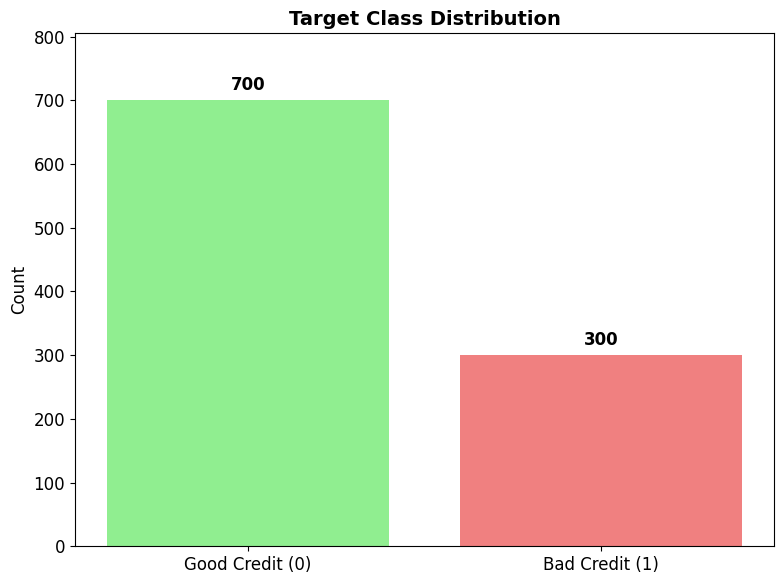

Saved: target_distribution.png


In [4]:
# Target class distribution
plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['Good Credit (0)', 'Bad Credit (1)'],
    target_counts.values,
    color=['lightgreen', 'lightcoral']
)
plt.title('Target Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.ylim(0, max(target_counts.values) * 1.15)
for bar, cnt in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(cnt), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: target_distribution.png')

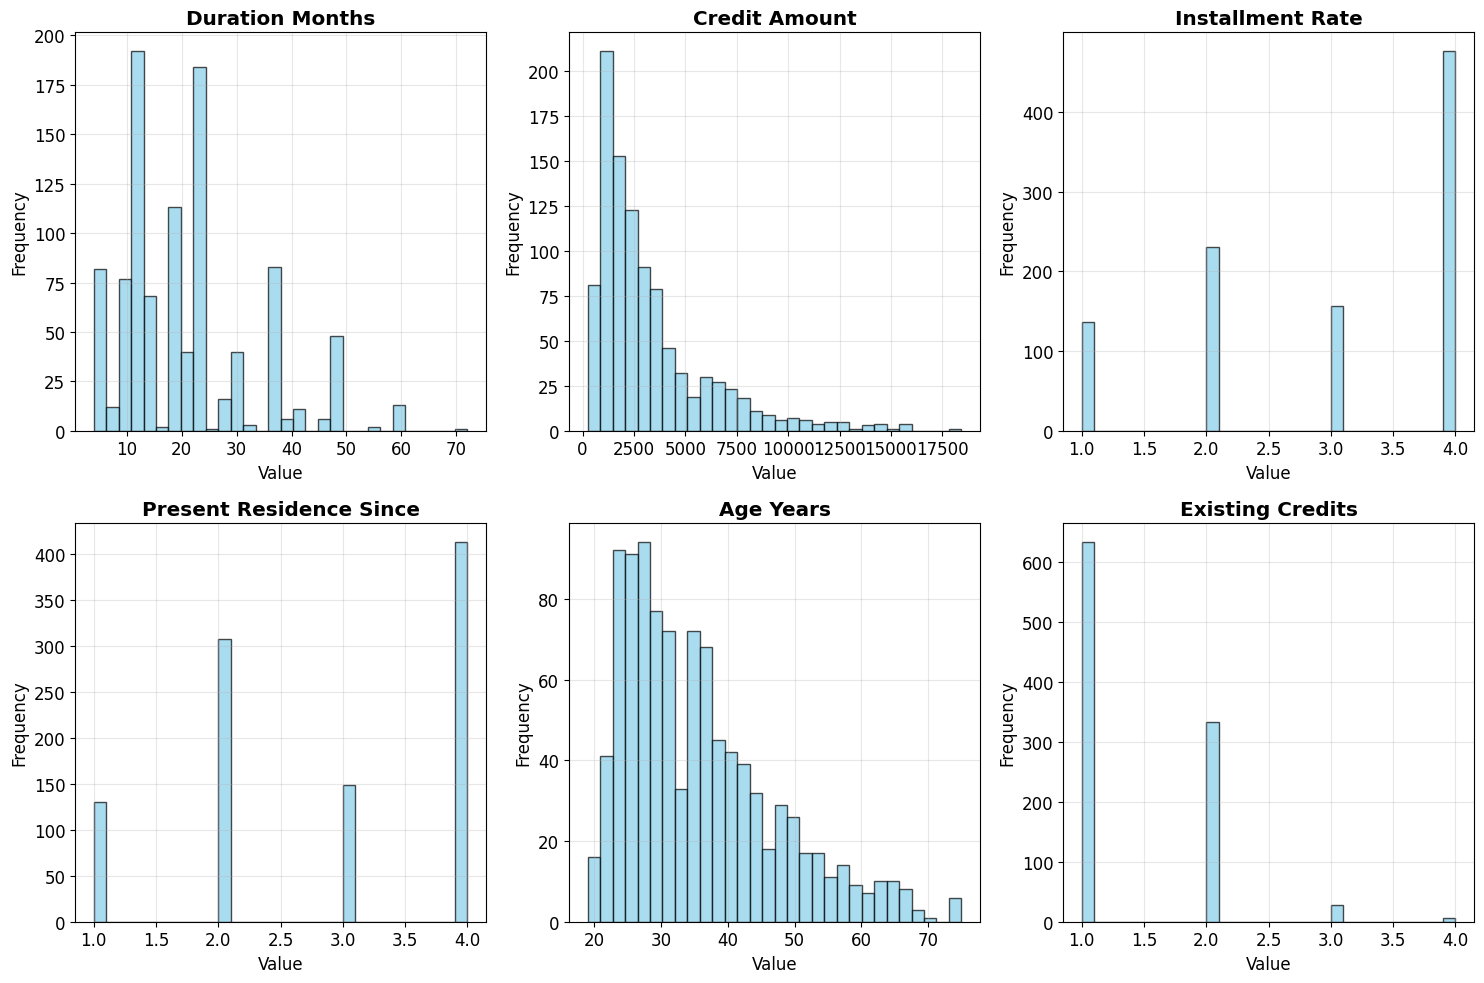

Saved: numeric_histograms.png


In [5]:
# Histograms for numeric features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numeric_columns):
    if i < len(axes):
        axes[i].hist(df[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numeric_histograms.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: numeric_histograms.png')

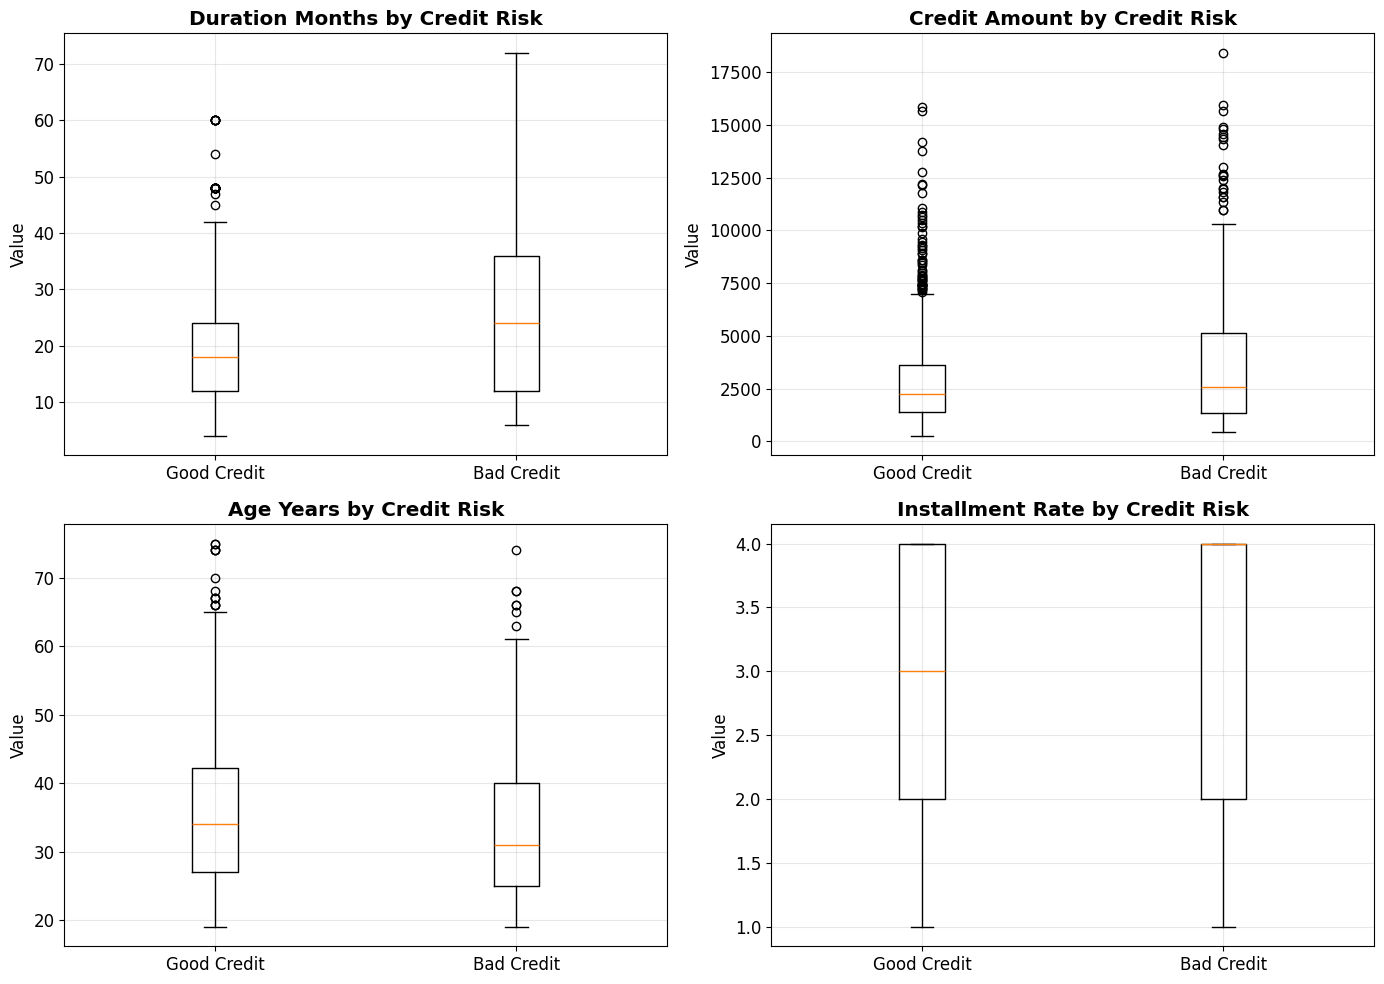

Saved: boxplots_by_target.png


In [6]:
# Boxplots of key numeric features by target
key_features = ['duration_months', 'credit_amount', 'age_years', 'installment_rate']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, feat in enumerate(key_features):
    axes[i].boxplot(
        [df[df['target'] == 0][feat], df[df['target'] == 1][feat]],
        labels=['Good Credit', 'Bad Credit']
    )
    axes[i].set_title(feat.replace('_', ' ').title() + ' by Credit Risk', fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplots_by_target.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: boxplots_by_target.png')

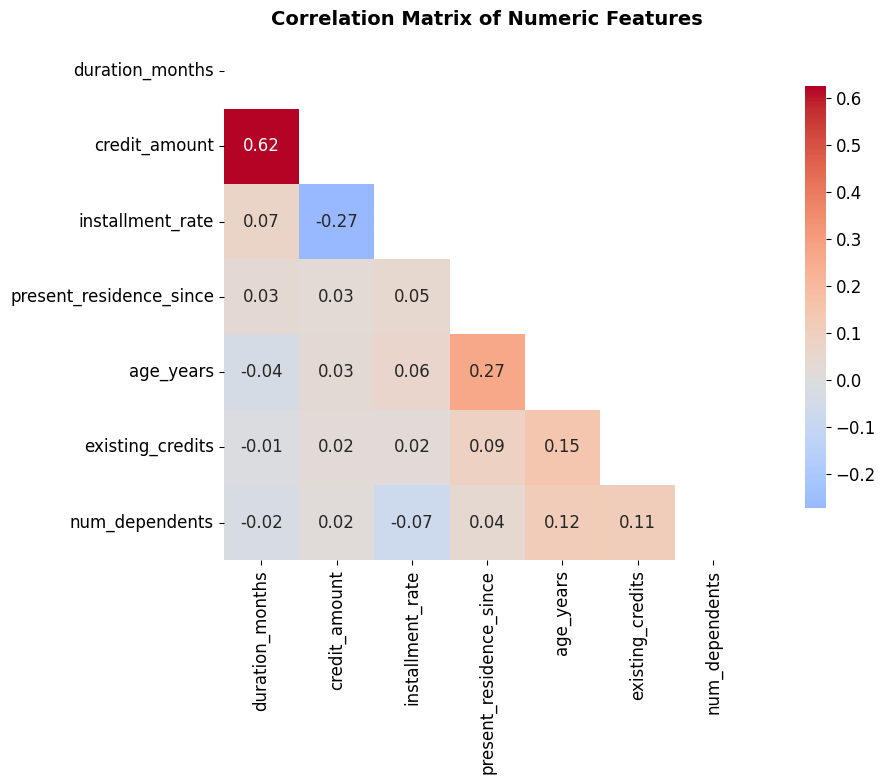

Saved: correlation_heatmap.png


In [7]:
# Correlation heatmap for numeric features
corr = df[numeric_columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: correlation_heatmap.png')

## E. Preprocessing and Feature Setup

In [8]:
# Identify feature types and split features/target
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features   = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target']

X = df.drop('target', axis=1)
y = df['target']

print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Numerical features   ({len(numerical_features)}): {numerical_features}')
print(f'\nX shape: {X.shape}  |  y shape: {y.shape}')

Categorical features (13): ['status_checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Numerical features   (7): ['duration_months', 'credit_amount', 'installment_rate', 'present_residence_since', 'age_years', 'existing_credits', 'num_dependents']

X shape: (1000, 20)  |  y shape: (1000,)


In [9]:
# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print('=== TRAIN-TEST SPLIT ===')
print(f'Training : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain target distribution:\n{y_train.value_counts().sort_index()}')
print(f'\nTest target distribution:\n{y_test.value_counts().sort_index()}')

=== TRAIN-TEST SPLIT ===
Training : 800 samples (80.0%)
Test     : 200 samples (20.0%)

Train target distribution:
target
0    560
1    240
Name: count, dtype: int64

Test target distribution:
target
0    140
1     60
Name: count, dtype: int64


In [10]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numerical_features),
    ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
])

print('Preprocessing pipeline:')
print('  Numeric  -> StandardScaler')
print('  Categorical -> OneHotEncoder (handle_unknown=ignore)')

Preprocessing pipeline:
  Numeric  -> StandardScaler
  Categorical -> OneHotEncoder (handle_unknown=ignore)


## F. Model Training

In [11]:
# Define four models spanning the interpretability spectrum
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_SEED, class_weight='balanced', max_depth=10
    ),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_SEED, class_weight='balanced', n_estimators=100, max_depth=10
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_SEED, n_estimators=100, max_depth=6
    )
}

trained_models = {}
print('=== TRAINING MODELS ===')
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f'  {name}: train_acc={pipeline.score(X_train, y_train):.4f}')

print('\nAll models trained successfully.')

=== TRAINING MODELS ===
  Logistic Regression: train_acc=0.7362
  Decision Tree: train_acc=0.9363
  Random Forest: train_acc=0.9825


  Gradient Boosting: train_acc=1.0000

All models trained successfully.


## G. Evaluation

In [12]:
# Evaluate all models on the test set
evaluation_results = []
confusion_matrices = {}
roc_curves         = {}

print('=== MODEL EVALUATION ===')
for name, pipeline in trained_models.items():
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    rec     = recall_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    evaluation_results.append({
        'Model': name, 'Accuracy': acc, 'Balanced Accuracy': bal_acc,
        'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    print(f'\n--- {name} ---')
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}')
    print(f'  Precision         : {prec:.4f}')
    print(f'  Recall            : {rec:.4f}')
    print(f'  F1-Score          : {f1:.4f}')
    print(f'  ROC-AUC           : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Bad Credit']))

    report_df = pd.DataFrame(
        classification_report(y_test, y_pred,
                              target_names=['Good Credit', 'Bad Credit'],
                              output_dict=True)
    ).transpose()
    report_df.to_csv(METRICS_DIR / f"{name.lower().replace(' ', '_')}_classification_report.csv")

=== MODEL EVALUATION ===

--- Logistic Regression ---
  Accuracy          : 0.7500
  Balanced Accuracy : 0.7643
  Precision         : 0.5581
  Recall            : 0.8000
  F1-Score          : 0.6575
  ROC-AUC           : 0.8058
              precision    recall  f1-score   support

 Good Credit       0.89      0.73      0.80       140
  Bad Credit       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200


--- Decision Tree ---
  Accuracy          : 0.6300
  Balanced Accuracy : 0.5929
  Precision         : 0.4054
  Recall            : 0.5000
  F1-Score          : 0.4478
  ROC-AUC           : 0.5749
              precision    recall  f1-score   support

 Good Credit       0.76      0.69      0.72       140
  Bad Credit       0.41      0.50      0.45        60

    accuracy                           0.63       200
   macro avg       0.58      0

In [13]:
# Model comparison table
comparison_df = pd.DataFrame(evaluation_results).round(4)
print('=== MODEL COMPARISON TABLE ===')
display(comparison_df)

comparison_df.to_csv(METRICS_DIR / 'model_comparison.csv', index=False)
comparison_df.to_csv(TABLES_DIR  / 'model_comparison.csv', index=False)
print('Saved: model_comparison.csv')

=== MODEL COMPARISON TABLE ===


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.750,0.7643,0.5581,0.8000,0.6575,0.8058
1,Decision Tree,0.630,0.5929,0.4054,0.5000,0.4478,0.5749
2,Random Forest,0.775,0.6917,0.6744,0.4833,0.5631,0.8002
3,Gradient Boosting,0.755,0.6821,0.6122,0.5000,0.5505,0.7640


Saved: model_comparison.csv


In [14]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = []

print('=== 5-FOLD CROSS-VALIDATION (ROC-AUC) ===')
for name, pipeline in trained_models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'CV_ROC_AUC_Mean': round(scores.mean(), 4),
        'CV_ROC_AUC_Std':  round(scores.std(), 4)
    })
    print(f'  {name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})')

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(METRICS_DIR / 'cross_validation_results.csv', index=False)
cv_df.to_csv(TABLES_DIR  / 'cross_validation_results.csv', index=False)
display(cv_df)
print('Saved: cross_validation_results.csv')

=== 5-FOLD CROSS-VALIDATION (ROC-AUC) ===
  Logistic Regression: 0.7687 (+/- 0.1060)


  Decision Tree: 0.6319 (+/- 0.0615)


  Random Forest: 0.7894 (+/- 0.0751)


  Gradient Boosting: 0.7781 (+/- 0.0703)


,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.7687,0.0530
1,Decision Tree,0.6319,0.0308
2,Random Forest,0.7894,0.0375
3,Gradient Boosting,0.7781,0.0352


Saved: cross_validation_results.csv


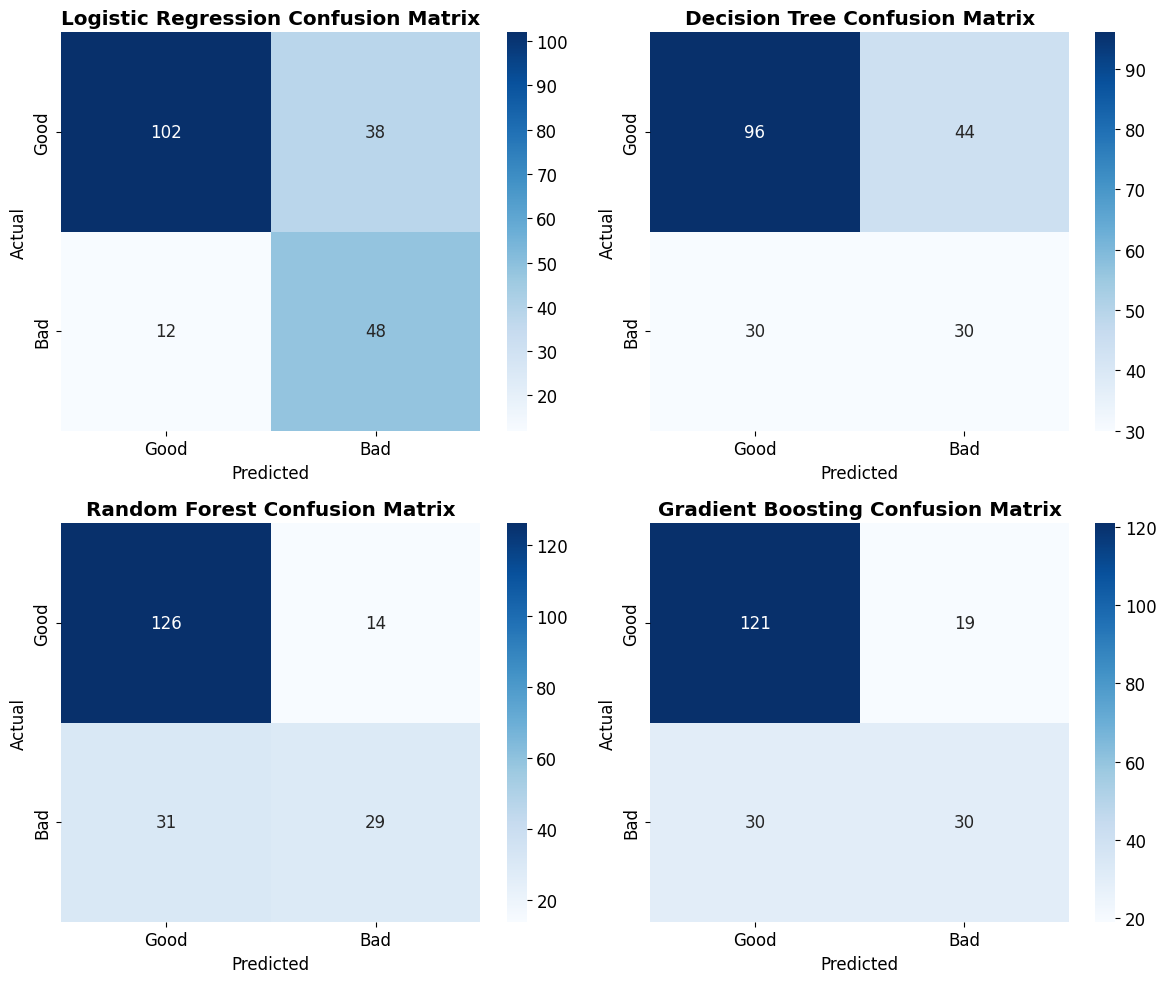

Saved: confusion_matrices.png


In [15]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    axes[i].set_title(f'{name} Confusion Matrix', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: confusion_matrices.png')

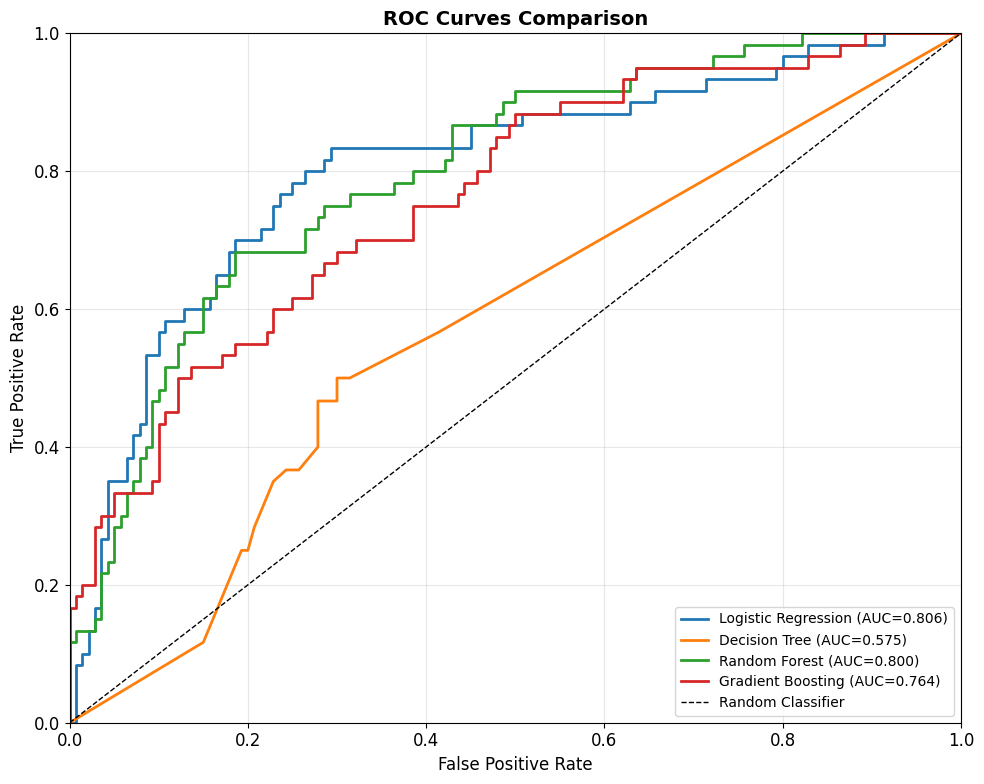

Saved: roc_curves.png


In [16]:
# ROC curves comparison
plt.figure(figsize=(10, 8))
for name, roc in roc_curves.items():
    plt.plot(roc['fpr'], roc['tpr'], label=f"{name} (AUC={roc['auc']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: roc_curves.png')

## H. Explainability

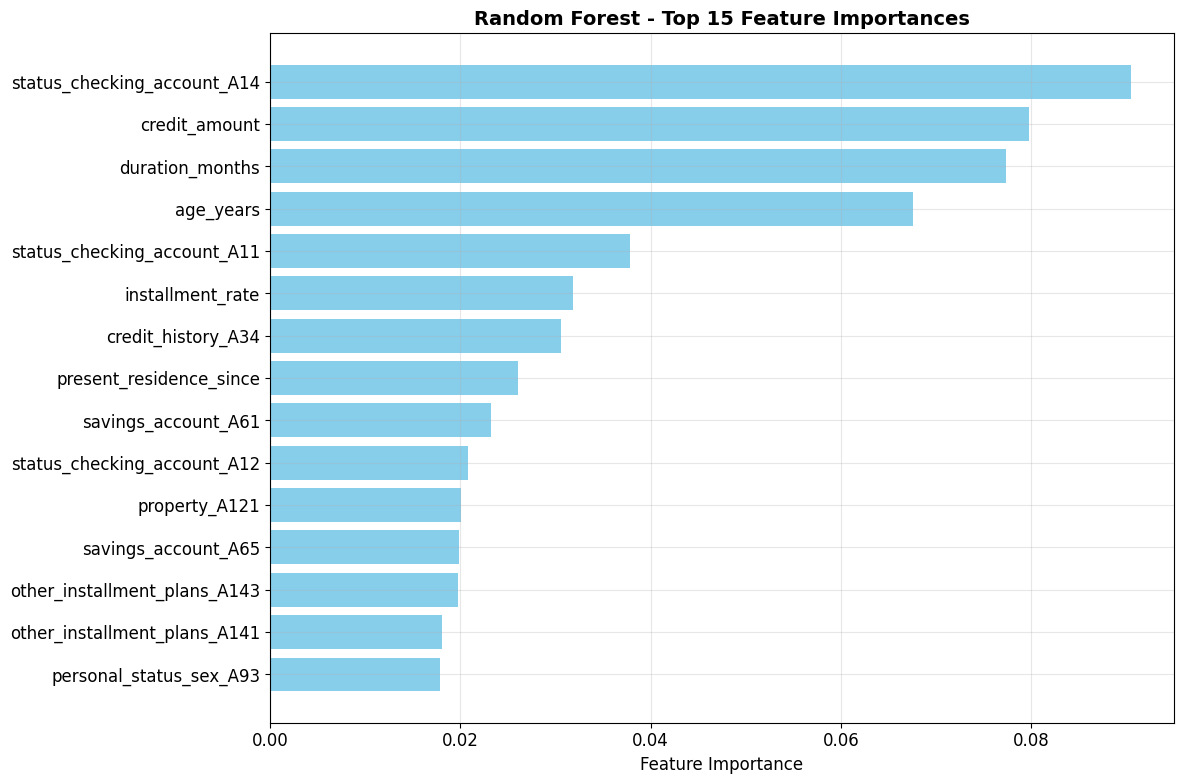

Saved: random_forest_feature_importance.png

Top 10 most important features:


,feature,importance
10,status_checking_account_A14,0.090463
1,credit_amount,0.079768
0,duration_months,0.077338
4,age_years,0.067583
7,status_checking_account_A11,0.037839
2,installment_rate,0.031815
15,credit_history_A34,0.030552
3,present_residence_since,0.026030
26,savings_account_A61,0.023186
8,status_checking_account_A12,0.020829


In [17]:
# Random Forest feature importances
rf_pipeline = trained_models['Random Forest']
rf_model    = rf_pipeline.named_steps['classifier']

feature_names = (
    numerical_features +
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features).tolist()
)

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_fi = feature_importance_df.head(15)
plt.barh(range(len(top_fi)), top_fi['importance'], color='skyblue')
plt.yticks(range(len(top_fi)), top_fi['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Random Forest - Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: random_forest_feature_importance.png')

print('\nTop 10 most important features:')
display(feature_importance_df.head(10))

feature_importance_df.to_csv(METRICS_DIR / 'random_forest_feature_importance.csv', index=False)

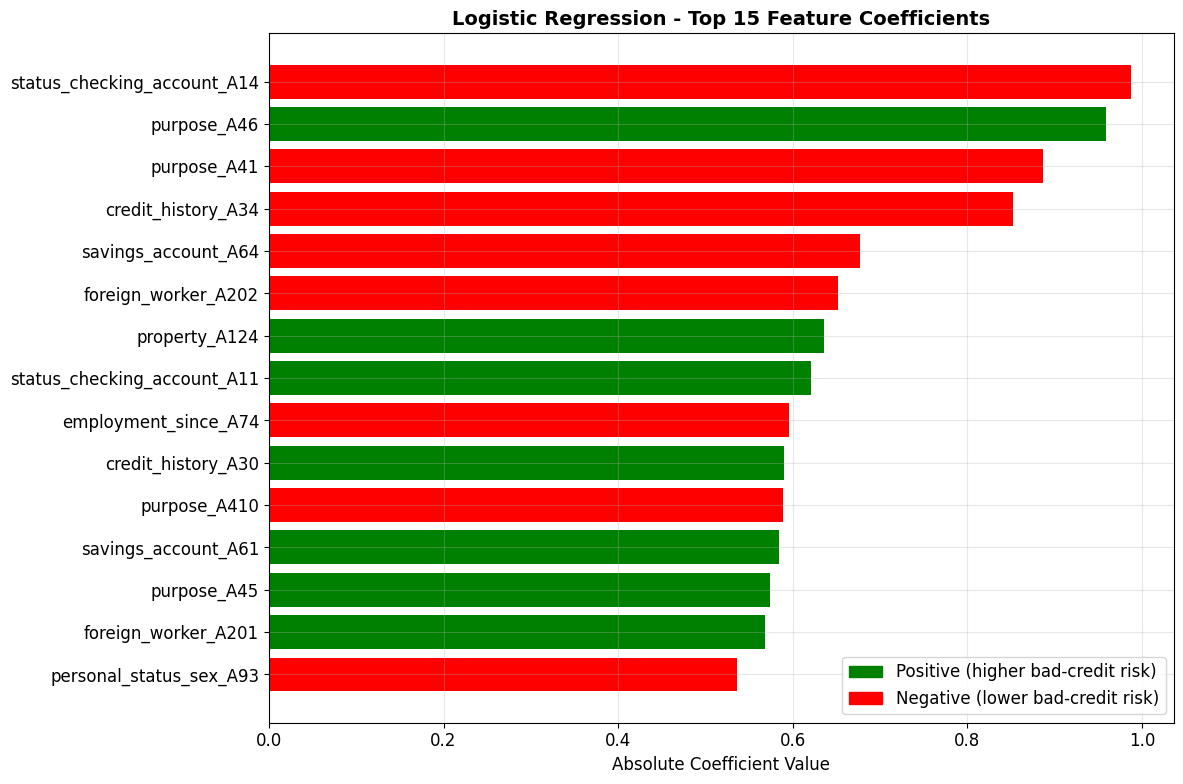

Saved: logistic_regression_coefficients.png

Top 10 most influential features:


,feature,coefficient,abs_coefficient
10,status_checking_account_A14,-0.987410,0.987410
23,purpose_A46,0.958526,0.958526
17,purpose_A41,-0.887080,0.887080
15,credit_history_A34,-0.852003,0.852003
29,savings_account_A64,-0.676792,0.676792
60,foreign_worker_A202,-0.651421,0.651421
46,property_A124,0.635350,0.635350
7,status_checking_account_A11,0.620797,0.620797
34,employment_since_A74,-0.595362,0.595362
11,credit_history_A30,0.589948,0.589948


In [18]:
# Logistic Regression coefficients
lr_pipeline = trained_models['Logistic Regression']
lr_model    = lr_pipeline.named_steps['classifier']

lr_feature_names = (
    numerical_features +
    lr_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features).tolist()
)

coefficient_df = pd.DataFrame({
    'feature':         lr_feature_names,
    'coefficient':     lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(12, 8))
top_cf = coefficient_df.head(15)
colors = ['red' if x < 0 else 'green' for x in top_cf['coefficient']]
plt.barh(range(len(top_cf)), top_cf['abs_coefficient'], color=colors)
plt.yticks(range(len(top_cf)), top_cf['feature'])
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.title('Logistic Regression - Top 15 Feature Coefficients', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.legend(handles=[
    mpatches.Patch(color='green', label='Positive (higher bad-credit risk)'),
    mpatches.Patch(color='red',   label='Negative (lower bad-credit risk)')
])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistic_regression_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: logistic_regression_coefficients.png')

print('\nTop 10 most influential features:')
display(coefficient_df.head(10))

coefficient_df.to_csv(METRICS_DIR / 'logistic_regression_coefficients.csv', index=False)

In [19]:
# SHAP analysis (optional - requires shap package)
if SHAP_AVAILABLE:
    try:
        print('=== SHAP ANALYSIS FOR RANDOM FOREST ===')
        X_train_processed = rf_pipeline.named_steps['preprocessor'].transform(X_train)
        explainer   = shap.TreeExplainer(rf_model)
        shap_values = explainer.shap_values(X_train_processed)

        shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values_class1, X_train_processed,
                          feature_names=feature_names, show=False, max_display=15)
        plt.title('SHAP Summary Plot - Random Forest', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'shap_summary_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print('Saved: shap_summary_plot.png')
    except Exception as e:
        print(f'SHAP analysis failed: {e}')
else:
    print('SHAP not available. Install with: pip install shap')

SHAP not available. Install with: pip install shap


## I. Final Summary

In [20]:
# List all saved outputs
print('=== SAVED OUTPUTS ===')
for label, directory in [('Figures', FIGURES_DIR), ('Tables', TABLES_DIR), ('Metrics', METRICS_DIR)]:
    print(f'\n{label}:')
    for f in sorted(directory.glob('*')):
        print(f'  - {f.name}')

# Best model summary
best_by_auc = comparison_df.loc[comparison_df['ROC-AUC'].idxmax()]
best_by_acc = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print('\n=== FINAL SUMMARY ===')
print(f'Dataset       : {len(df)} samples, {len(df.columns)-1} features')
print(f'Class balance : {target_percentages[0]:.1f}% Good Credit / {target_percentages[1]:.1f}% Bad Credit')
print(f'Features      : {len(categorical_features)} categorical, {len(numerical_features)} numerical')
print()
print(f'Best by ROC-AUC          : {best_by_auc["Model"]} (AUC={best_by_auc["ROC-AUC"]:.4f}, Bal.Acc={best_by_auc["Balanced Accuracy"]:.4f})')
print(f'Best by Accuracy         : {best_by_acc["Model"]} ({best_by_acc["Accuracy"]:.4f})')
print()
print('Performance Ranking (ROC-AUC):')
for i, (_, row) in enumerate(comparison_df.sort_values('ROC-AUC', ascending=False).iterrows(), 1):
    print(f'  {i}. {row["Model"]}: AUC={row["ROC-AUC"]:.4f}  Bal.Acc={row["Balanced Accuracy"]:.4f}')
print()
print('Top 3 predictive features (Random Forest):')
for i, feat in enumerate(feature_importance_df.head(3)['feature'], 1):
    print(f'  {i}. {feat}')
print()
print('=' * 55)
print(f'ANALYSIS COMPLETE. Results saved to: {PROJECT_ROOT / "results"}')
print('=' * 55)

=== SAVED OUTPUTS ===

Figures:
  - boxplots_by_target.png
  - confusion_matrices.png
  - correlation_heatmap.png
  - logistic_regression_coefficients.png
  - numeric_histograms.png
  - random_forest_feature_importance.png
  - roc_curves.png
  - target_distribution.png

Tables:
  - cross_validation_results.csv
  - descriptive_stats.csv
  - model_comparison.csv

Metrics:
  - cross_validation_results.csv
  - decision_tree_classification_report.csv
  - gradient_boosting_classification_report.csv
  - logistic_regression_classification_report.csv
  - logistic_regression_coefficients.csv
  - model_comparison.csv
  - random_forest_classification_report.csv
  - random_forest_feature_importance.csv

=== FINAL SUMMARY ===
Dataset       : 1000 samples, 20 features
Class balance : 70.0% Good Credit / 30.0% Bad Credit
Features      : 13 categorical, 7 numerical

Best by ROC-AUC          : Logistic Regression (AUC=0.8058, Bal.Acc=0.7643)
Best by Accuracy         : Random Forest (0.7750)

Performance